# Inside the Eirenesphere: The Interplay of Porosity, Heat Flux and Mineralogy in Exoplanetary Aquable and Habitable Layers

## [Santiago A. Orjuela](mailto:santiagoa.orjuela@udea.edu.co) and [Jorge I. Zuluaga](mailto:jorge.zuluaga@udea.edu.co)

## Subsurface Aquable and Habitable Layers

This notebook analyzes the formation, extent, and parametric sensitivity of subsurface aquable and habitable layers in rocky planets. Using thermal structure models from `geotherm_calculator.py`, it evaluates how stellar irradiation and internal heat flow jointly control liquid-water stability and biologically viable environments within the lithosphere, including comparisons against the classical circumstellar habitable zone (Kopparapu et al. 2013).

### Libraries

**IMPORTANT**: Before running please install requirements with `pip install -r requirements.txt`. This notebook should be ran in the same directory as `geotherm_calculator.py`, `habitability_calculator.py`, `planetary_grid_reader.py`. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geotherm_calculator as gc
import habitability_calculator as hc

from astropy import constants as const
from iapws.iapws97 import IAPWS97
from iapws._iapws import _Sublimation_Pressure, _Melting_Pressure
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap


### Constants

In [2]:
G = const.G.value
R_gas = const.R.value
GPa = 1e9 #Pa
km = 1000 #m
mWm2 = 1e-3 #w/m2
den = 1000/100**3 #g/cm^-3
deg = 180/np.pi
rad = 1/deg

#Tierra
Me = const.M_earth.value
Re = const.R_earth.value
R_core = 0.55*Re
Tsurface = 288.0 

P_surf = 1e5     # Pa

### Plot Config

In [3]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
})


### HC Composition

In [4]:
comp_earth = gc.COMPOSITION_DEFAULT #Hasterok & Chapman
mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(mineral_objects=mineral_objects, composition=comp_earth)

### Layers Calculation

In [5]:
#Earth scenario
df_geotherm = gc.calculate_geotherm(
    rocks=rocks,
    q_s=65e-3,           # 65 mW/m²
    z_max=50e3,         # 10 km 
    dz=100.0,           
    R_planet=Re,
    M_total=Me,
    boundaries=gc.scale_layer_boundaries(Re),
    T_top=Tsurface,
    A_surface=2.5e-6,
    h_r=10e3
)

In [6]:
liquid_zone_data = hc.find_liquid_zone(df_geotherm, salinity=0.0)
habitable_zone_data = hc.find_habitable_zone(liquid_zone_data['indices'], 
                                             df_geotherm, 
                                             P_bio_max=200e6, T_bio_max=423.0, phi_min=1e-3)

hc.liq_hab_zone_data(liquid_zone_data, habitable_zone_data)


 Aquability Layer:
   Depth: 0.00 - 7.50 km
   Temperature: 288.00 - 435.92 K
   Pressure: 0.10 - 205.83 MPa
   Thickness: 7.500 km

 Habitable Layer :
   Depth: 0.00 - 6.70 km
   Temperature: 288.00 - 421.30 K (14.9 - 148.1°C)
   Pressure: 0.10 - 183.13 MPa
   Thickness: 6.700 km

📊 Habitable Layer = 89.3% of the Aquability Layer



In [7]:
#Earth scenario a 1.52 UA (Marte) 
a = 1.52  
Tsurf_152 = hc.T_eq(a)
print(f"Superficial Temperature at {a} au: {Tsurf_152:.2f} K ({Tsurf_152-273.15:.1f}°C)")

df_geotherm152 = gc.calculate_geotherm(
    rocks=rocks,
    q_s=65e-3,          
    z_max=50e3,        
    dz=100.0,           
    R_planet=Re,
    M_total=Me,
    boundaries=gc.scale_layer_boundaries(Re),
    T_top=Tsurf_152,
    A_surface=2.5e-6,
    h_r=10e3
)

Superficial Temperature at 1.52 au: 234.14 K (-39.0°C)


In [8]:
liquid_zone_data152 = hc.find_liquid_zone(df_geotherm152, salinity=0.0)
habitable_zone_data152 = hc.find_habitable_zone(liquid_zone_data152['indices'], df_geotherm152, P_bio_max=200e6,T_bio_max=423.0)

hc.liq_hab_zone_data(liquid_zone_data152, habitable_zone_data152)


 Aquability Layer:
   Depth: 1.70 - 7.50 km
   Temperature: 271.27 - 373.42 K
   Pressure: 43.82 - 206.18 MPa
   Thickness: 5.800 km

 Habitable Layer :
   Depth: 1.70 - 7.20 km
   Temperature: 271.27 - 368.35 K (-1.9 - 95.2°C)
   Pressure: 43.82 - 197.65 MPa
   Thickness: 5.500 km

📊 Habitable Layer = 94.8% of the Aquability Layer



## Circumstellar Habitable Zone  Kopparapu et al. (2013)

In [63]:
# Sun parameters
T_eff_sun = 5780.0  # K
L_star_sun = const.L_sun.value  # W

distances_kopparapu = {}
for limit_name in hc.HZ_LIMITS_KOPPARAPU_2013:
    distances_kopparapu[limit_name] = hc.hz_distance(T_eff_sun, L_star_sun, limit_name)

print("="*70)
print("Habitable Zone - Sol (Kopparapu et al. 2013)")
print("="*70)
print(f"\nStellar Parameters:")
print(f"  T_eff = {T_eff_sun} K")
print(f"  L = {L_star_sun/const.L_sun.value:.2f} L_sun")
print(f"\nCONSERVATIVE LIMITS:")
print(f"  Moist Greenhouse (in):  {distances_kopparapu['Moist Greenhouse']:.4f} AU")
print(f"  Runaway Greenhouse (in): {distances_kopparapu['Runaway Greenhouse']:.4f} AU")
print(f"  Maximum Greenhouse (out): {distances_kopparapu['Maximum Greenhouse']:.4f} AU")
print(f"\nOPTIMISTIC LIMITS:")
print(f"  Recent Venus (in):       {distances_kopparapu['Recent Venus']:.4f} AU")
print(f"  Early Mars (out):         {distances_kopparapu['Early Mars']:.4f} AU")
print(f"\nHabitable Zone (Conservative):  {distances_kopparapu['Moist Greenhouse']:.4f} - {distances_kopparapu['Maximum Greenhouse']:.4f} AU")
print(f"Habitable Zone (Optimistic):     {distances_kopparapu['Recent Venus']:.4f} - {distances_kopparapu['Early Mars']:.4f} AU")
print("="*70)

Habitable Zone - Sol (Kopparapu et al. 2013)

Stellar Parameters:
  T_eff = 5780.0 K
  L = 1.00 L_sun

CONSERVATIVE LIMITS:
  Moist Greenhouse (in):  0.9928 AU
  Runaway Greenhouse (in): 0.9813 AU
  Maximum Greenhouse (out): 1.6886 AU

OPTIMISTIC LIMITS:
  Recent Venus (in):       0.7503 AU
  Early Mars (out):         1.7658 AU

Habitable Zone (Conservative):  0.9928 - 1.6886 AU
Habitable Zone (Optimistic):     0.7503 - 1.7658 AU


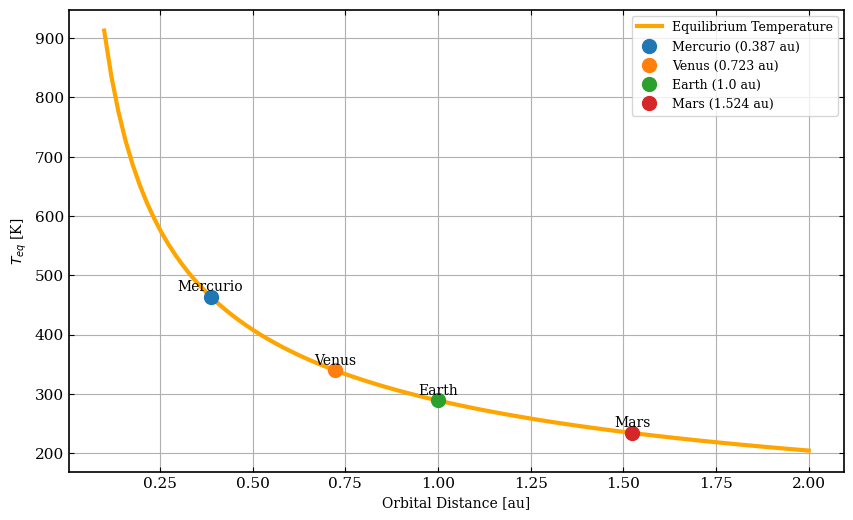

In [66]:
ds = np.linspace(0.1, 2.0, 100)
T_eqs = [hc.T_eq(distance_AU=d) for d in ds]

planets = {
    'Mercurio': 0.387,
    'Venus': 0.723,
    'Earth': 1.000,
    'Mars': 1.524,
}

plt.figure(figsize=(10, 6))
plt.plot(ds, T_eqs, 'orange', linewidth=3, label='Equilibrium Temperature')
for planet, d in planets.items():
    T_eq_planet = hc.T_eq(distance_AU=d)
    plt.plot(d, T_eq_planet, 'o', markersize=10, label=f'{planet} ({d} au)')
    plt.text(d, T_eq_planet + 10, planet, fontsize=10, ha='center')

'''
plt.axvline(distances_kopparapu['Moist Greenhouse'], color='green', linestyle='--', linewidth=2)
plt.axvline(distances_kopparapu['Maximum Greenhouse'], color='green', linestyle='--', linewidth=2)

plt.axvline(distances_kopparapu['Recent Venus'], color='blue', linestyle='--', linewidth=2)
plt.axvline(distances_kopparapu['Early Mars'], color='blue', linestyle='--', linewidth=2)
plt.fill_betweenx([0, 900], distances_kopparapu['Recent Venus'], distances_kopparapu['Early Mars'], 
                 color='lightblue', alpha=0.2, label='Optimistic Habitable Zone')
plt.fill_betweenx([0, 900], distances_kopparapu['Moist Greenhouse'], distances_kopparapu['Maximum Greenhouse'], 
                 color='lightgreen', alpha=0.3, label='Conservative Habitable Zone')
                 
'''

plt.xlabel('Orbital Distance [au]', fontsize=10)
plt.ylabel('$T_{eq}$ [K]', fontsize=10)
plt.legend()
plt.grid(True)
plt.show()


### Zona Habitable vs Distancia Orbital


In [71]:
def habitability_vs_distance(
    Planet_Mass,
    Planet_Radius,
    Heat_Flux,
    Max_distance,
    Min_distance=0.5,
    ndistances=30
):    
    
    distances_AU = np.linspace(Min_distance, Max_distance, ndistances)  
    water_thickness = []
    habitable_thickness = []
    water_depth_start = []
    habitable_depth_start = []
    surface_temps = []

    boundaries = gc.scale_layer_boundaries(R_planet=Planet_Radius * Re)

    for d_AU in distances_AU:
        # Calcular temperatura superficial
        T_surf = hc.T_eq(distance_AU=d_AU)
        surface_temps.append(T_surf)
        
        # Calcular perfil geotérmico
        df_temp = gc.calculate_geotherm(
            rocks=rocks,
            q_s=Heat_Flux * 1e-3,
            z_max=15e3,
            dz=100.0,
            R_planet=Planet_Radius * Re,
            M_total=Planet_Mass * Me,
            boundaries=boundaries,
            T_top=T_surf,
            A_surface=2.5e-6,
            h_r=10e3
        )
        
        liquid_data = hc.find_liquid_zone(df_temp, salinity=0.0, information=False)
        habitable_data = hc.find_habitable_zone(liquid_data['indices'], df_temp, P_bio_max=200e6, T_bio_max=423.15,
                                                information=False)

        # Guardar espesores y profundidades iniciales
        if liquid_data['liquid_zone'] is not None:
            water_thick = (liquid_data['liquid_zone'][-1] - liquid_data['liquid_zone'][0]) / 1000  # km
            water_thickness.append(water_thick)
            water_depth_start.append(liquid_data['liquid_zone'][0] / 1000)  # km
        else:
            water_thickness.append(0)
            water_depth_start.append(np.nan)
        
        if habitable_data['habitable_zone'] is not None:
            hab_thick = (habitable_data['habitable_zone'][-1] - habitable_data['habitable_zone'][0]) / 1000  # km
            habitable_thickness.append(hab_thick)
            habitable_depth_start.append(habitable_data['habitable_zone'][0] / 1000)  # km
        else:
            habitable_thickness.append(0)
            habitable_depth_start.append(np.nan)
        

    # Convertir a arrays numpy
    water_thickness = np.array(water_thickness)
    habitable_thickness = np.array(habitable_thickness)
    water_depth_start = np.array(water_depth_start)
    habitable_depth_start = np.array(habitable_depth_start)
    surface_temps = np.array(surface_temps)

    data = {
        'distances_AU': distances_AU,
        'water_thickness': water_thickness,
        'habitable_thickness': habitable_thickness,
        'water_depth_start': water_depth_start,
        'habitable_depth_start': habitable_depth_start,
        'surface_temps': surface_temps,
        'attributes': {
            'Planet_Mass': Planet_Mass,
            'Planet_Radius': Planet_Radius,
            'Heat_Flux': Heat_Flux,
        }
    }


    return data

In [70]:
data = habitability_vs_distance(
    Planet_Mass=1.0,
    Planet_Radius=1.0,
    Heat_Flux=65.0,
    Max_distance=6.0,
    Min_distance=0.1,
    ndistances=100
)

np.savez('habitability_vs_distance_earth.npz', **data)

CALCULANDO CapaS DE HABITABILIDAD PARA DIFERENTES DISTANCIAS ORBITALES



📊 Eirenesphere Max Layer Thickness:
   Distance: 1.05 AU
   Thickness: 7.20 km
   Upper Layer Depth: 0.00 km
   Surface Temperature: 281.2 K (8.1°C)

 Aquability Layer Max Thickness:
   Distance: 0.64 AU
   Thickness: 7.60 km
   Upper Layer Depth: 0.00 km

 Aquability Range:
   From: 0.28 AU (T_surf = 546.7 K)
   To: 5.94 AU (T_surf = 118.4 K)
   Total range: 5.66 AU

 Planet Parameters:
   Mass: 1.00 M⊕
   Radius: 1.00 R⊕
   Internal Heat Flux: 65.0 mW/m²
   Average Density: 1.00 ρ⊕



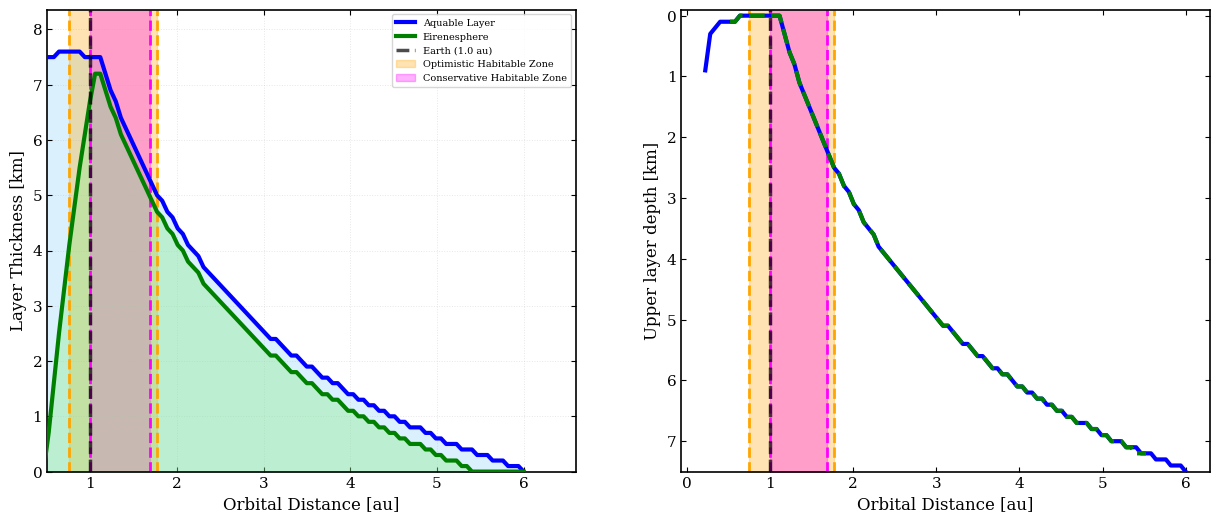

In [73]:
distances_AU = data['distances_AU']
water_thickness = data['water_thickness']
habitable_thickness = data['habitable_thickness']
water_depth_start = data['water_depth_start']
habitable_depth_start = data['habitable_depth_start']
surface_temps = data['surface_temps']

attributes = data['attributes']
Planet_Mass = attributes['Planet_Mass']
Planet_Radius = attributes['Planet_Radius']
Heat_Flux = attributes['Heat_Flux']

plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


ax1.plot(distances_AU, water_thickness, 'b-', linewidth=3,
        markersize=6, label='Aquable Layer', zorder=3)
ax1.plot(distances_AU, habitable_thickness, 'g-', linewidth=3,
        markersize=6, label='Eirenesphere', zorder=3)
ax1.fill_between(distances_AU, 0, water_thickness, color='lightskyblue', alpha=0.3, zorder=1)
ax1.fill_between(distances_AU, 0, habitable_thickness, color='lightgreen', alpha=0.4, zorder=2)

# Marcar posición de la Tierra
ax1.axvline(1.0, color='black', linestyle='--', linewidth=2.5, alpha=0.7, 
            label='Earth (1.0 au)', zorder=4)

ax1.set_xlabel('Orbital Distance [au]')
ax1.set_ylabel('Layer Thickness [km]')
ax1.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
ax1.set_xlim(0.5, max(distances_AU)*1.1)
if max(water_thickness) > 0:
    ax1.set_ylim(0, max(water_thickness) * 1.1)
    
#limites de Kopparapu
ax1.axvline(distances_kopparapu['Moist Greenhouse'], color='magenta', linestyle='--', linewidth=2)
ax1.axvline(distances_kopparapu['Maximum Greenhouse'], color='magenta', linestyle='--', linewidth=2)

ax1.axvline(distances_kopparapu['Recent Venus'], color='Orange', linestyle='--', linewidth=2)
ax1.axvline(distances_kopparapu['Early Mars'], color='Orange', linestyle='--', linewidth=2)
ax1.fill_betweenx([0, 900], distances_kopparapu['Recent Venus'], distances_kopparapu['Early Mars'], 
                 color='orange', alpha=0.3, label='Optimistic Habitable Zone')
ax1.fill_betweenx([0, 900], distances_kopparapu['Moist Greenhouse'], distances_kopparapu['Maximum Greenhouse'], 
                 color='magenta', alpha=0.3, label='Conservative Habitable Zone')
ax1.legend( loc='upper right', fontsize=7, framealpha=0.8)

    

valid_hab = ~np.isnan(habitable_depth_start)
valid_water = ~np.isnan(water_depth_start)
if valid_water.any():
    ax2.plot(distances_AU[valid_water], water_depth_start[valid_water], 'b-', 
            linewidth=3, label='Aquable Layer', zorder=3)

if valid_hab.any():
        ax2.plot(distances_AU[valid_hab], habitable_depth_start[valid_hab], 'g--', 
                linewidth=3, label='Habitable Layer', zorder=3)

    
    # Marcar posición de la Tierra
ax2.axvline(1.0, color='black', linestyle='--', linewidth=2.5, alpha=0.7, 
                label='Earth (1.0 au)', zorder=4)
    
ax2.set_xlabel('Orbital Distance [au]')
ax2.set_ylabel('Upper layer depth [km]')

#limites de Kopparapu
ax2.axvline(distances_kopparapu['Moist Greenhouse'], color='magenta', linestyle='--', linewidth=2)
ax2.axvline(distances_kopparapu['Maximum Greenhouse'], color='magenta', linestyle='--', linewidth=2)

ax2.axvline(distances_kopparapu['Recent Venus'], color='Orange', linestyle='--', linewidth=2)
ax2.axvline(distances_kopparapu['Early Mars'], color='Orange', linestyle='--', linewidth=2)
ax2.fill_betweenx([-1, 7.5], distances_kopparapu['Recent Venus'], distances_kopparapu['Early Mars'], 
                 color='orange', alpha=0.3, label='Optimistic Habitable Zone')
ax2.fill_betweenx([-1, 7.5], distances_kopparapu['Moist Greenhouse'], distances_kopparapu['Maximum Greenhouse'], 
                 color='magenta', alpha=0.3, label='Conservative Habitable Zone')
ax2.set_ylim(-0.1, 7.5)

ax2.invert_yaxis() 

if habitable_thickness.max() > 0:
        max_hab_idx = np.argmax(habitable_thickness)
        print(f"\n📊 Eirenesphere Max Layer Thickness:")
        print(f"   Distance: {distances_AU[max_hab_idx]:.2f} AU")
        print(f"   Thickness: {habitable_thickness[max_hab_idx]:.2f} km")
        print(f"   Upper Layer Depth: {habitable_depth_start[max_hab_idx]:.2f} km")
        print(f"   Surface Temperature: {surface_temps[max_hab_idx]:.1f} K ({surface_temps[max_hab_idx]-273.15:.1f}°C)")
    
if water_thickness.max() > 0:
        max_water_idx = np.argmax(water_thickness)
        print(f"\n Aquability Layer Max Thickness:")
        print(f"   Distance: {distances_AU[max_water_idx]:.2f} AU")
        print(f"   Thickness: {water_thickness[max_water_idx]:.2f} km")
        print(f"   Upper Layer Depth: {water_depth_start[max_water_idx]:.2f} km")
    
    # Distance donde aparece agua líquida subsuperficial
water_exists = water_thickness > 0
if water_exists.any():
        first_water_idx = np.where(water_exists)[0][0]
        last_water_idx = np.where(water_exists)[0][-1]
        print(f"\n Aquability Range:")
        print(f"   From: {distances_AU[first_water_idx]:.2f} AU (T_surf = {surface_temps[first_water_idx]:.1f} K)")
        print(f"   To: {distances_AU[last_water_idx]:.2f} AU (T_surf = {surface_temps[last_water_idx]:.1f} K)")
        print(f"   Total range: {distances_AU[last_water_idx] - distances_AU[first_water_idx]:.2f} AU")
    
print(f"\n Planet Parameters:")
print(f"   Mass: {Planet_Mass:.2f} M⊕")
print(f"   Radius: {Planet_Radius:.2f} R⊕")
print(f"   Internal Heat Flux: {Heat_Flux:.1f} mW/m²")
print(f"   Average Density: {(Planet_Mass/Planet_Radius**3):.2f} ρ⊕")
print("\n" + "=" * 80)
            

### Parametric Analysis

In [18]:
def habitability_vs_distance_heatflux(max_distance,
                                      min_distance=0.1,
                                        ndistances=6,
                                      max_heatflux=200e-3,
                                      min_heatflux=20e-3,
                                      nheatfluxes=6):

    ds = np.linspace(min_distance, max_distance, ndistances)
    qs = np.linspace(min_heatflux, max_heatflux, nheatfluxes)

    water_thickness_grid = np.zeros((len(ds), len(qs)))
    habitable_thickness_grid = np.zeros((len(ds), len(qs)))
    water_depth_top_grid = np.zeros((len(ds), len(qs)))
    water_depth_bottom_grid = np.zeros((len(ds), len(qs)))
    habitable_depth_top_grid = np.zeros((len(ds), len(qs)))
    habitable_depth_bottom_grid = np.zeros((len(ds), len(qs)))
    


    for i, distance in enumerate(ds):
        print(f'Distancia: {distance}')
        for j, q in enumerate(qs):
            T_surf = hc.T_eq(distance_AU=distance)
            
            df_geotherm_sim = gc.calculate_geotherm(
                rocks=rocks,
                q_s=q,
                z_max=15e3,
                dz=100.0,
                R_planet=Re,
                M_total=Me,
                boundaries=gc.scale_layer_boundaries(R_planet=Re),
                T_top=T_surf,
                A_surface=gc.A0(q),
                h_r=10e3
            )

            liquid_zone_data = hc.find_liquid_zone(df_geotherm_sim, salinity=0.0, information=False)
            
            if liquid_zone_data['liquid_zone'] is not None:
                habitable_zone_data = hc.find_habitable_zone(liquid_zone_data['indices'], df_geotherm_sim, information=False)
                

                water_thickness_grid[i, j] = (liquid_zone_data['liquid_zone'][-1] - liquid_zone_data['liquid_zone'][0]) / 1000  # km
                water_depth_top_grid[i, j] = liquid_zone_data['liquid_zone'][0] / 1000  # km
                water_depth_bottom_grid[i, j] = liquid_zone_data['liquid_zone'][-1] / 1000  # km

                # Verificar zona habitable
                if habitable_zone_data is not None and habitable_zone_data['habitable_zone'] is not None:

                    habitable_thickness_grid[i, j] = (habitable_zone_data['habitable_zone'][-1] - habitable_zone_data['habitable_zone'][0]) / 1000  # km
                    habitable_depth_top_grid[i, j] = habitable_zone_data['habitable_zone'][0] / 1000  # km
                    habitable_depth_bottom_grid[i, j] = habitable_zone_data['habitable_zone'][-1] / 1000  # km

    data_grid = {
        'distances_AU': ds,
        'heat_fluxes': qs,
        'water_thickness_grid': water_thickness_grid,
        'habitable_thickness_grid': habitable_thickness_grid,
        'water_depth_top_grid': water_depth_top_grid,
        'water_depth_bottom_grid': water_depth_bottom_grid,
        'habitable_depth_top_grid': habitable_depth_top_grid,
        'habitable_depth_bottom_grid': habitable_depth_bottom_grid,
    }
    return data_grid

In [26]:
data_grid = habitability_vs_distance_heatflux(max_distance=7.0,
                                              min_distance=0.1,
                                              ndistances=30,
                                              nheatfluxes=10,
                                              max_heatflux=200e-3,
                                              min_heatflux=20e-3)

Distancia: 0.1
Distancia: 0.33793103448275863
Distancia: 0.5758620689655173
Distancia: 0.8137931034482758
Distancia: 1.0517241379310345
Distancia: 1.2896551724137932
Distancia: 1.5275862068965518
Distancia: 1.7655172413793105
Distancia: 2.003448275862069
Distancia: 2.241379310344828
Distancia: 2.4793103448275864
Distancia: 2.717241379310345
Distancia: 2.9551724137931035
Distancia: 3.193103448275862
Distancia: 3.431034482758621
Distancia: 3.6689655172413795
Distancia: 3.906896551724138
Distancia: 4.144827586206897
Distancia: 4.382758620689655
Distancia: 4.620689655172414
Distancia: 4.858620689655172
Distancia: 5.096551724137931
Distancia: 5.334482758620689
Distancia: 5.572413793103448
Distancia: 5.810344827586206
Distancia: 6.048275862068965
Distancia: 6.2862068965517235
Distancia: 6.524137931034483
Distancia: 6.7620689655172415
Distancia: 7.0


In [ ]:
np.savez('habitability_distance_heatflux_grid.npz', **data_grid)

In [75]:
data_grid = np.load('habitability_distance_heatflux_grid.npz')

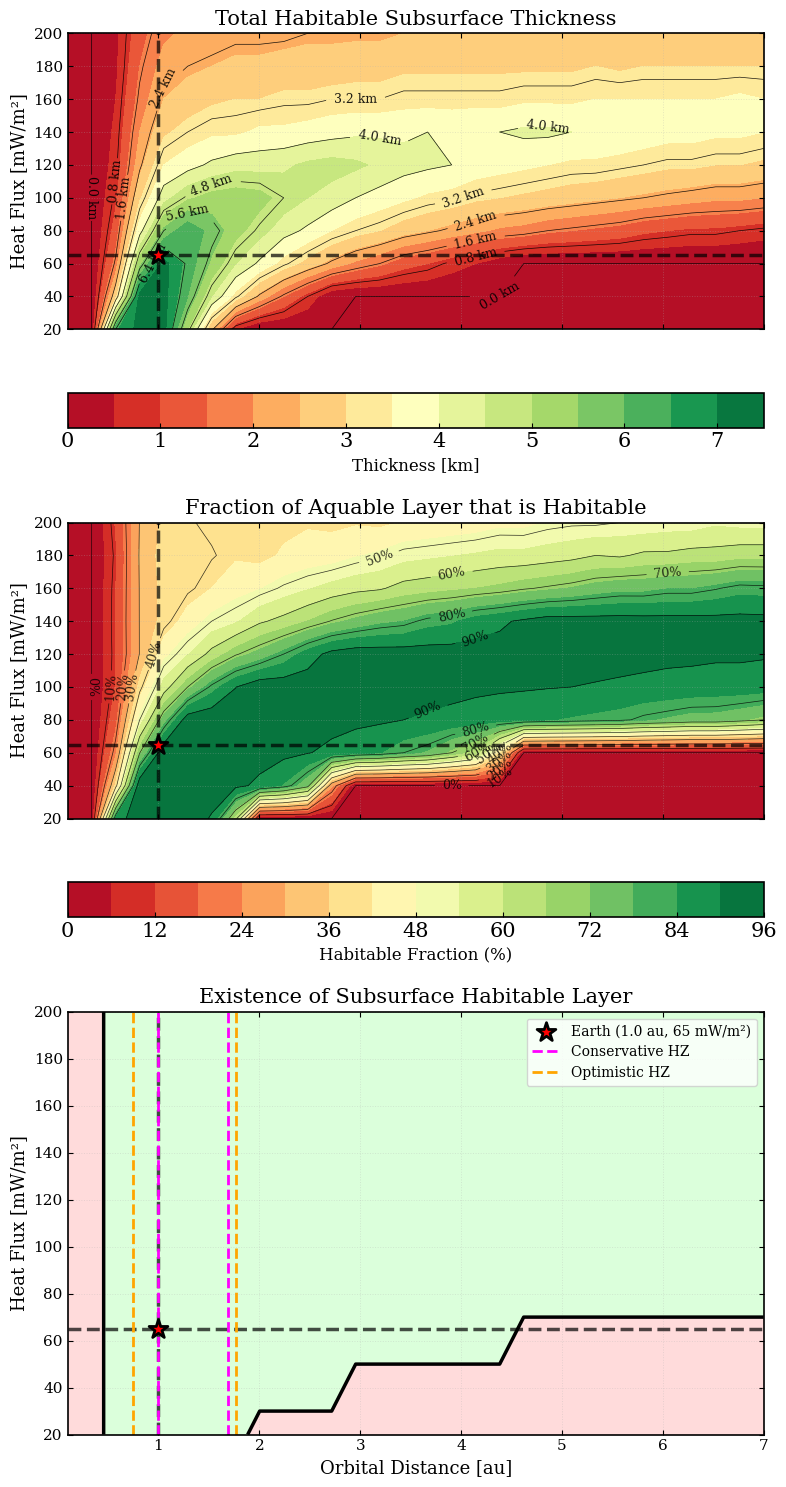


📊 Aquability Zone:
   Maximum Thickness: 7.60 km
   At: d = 0.81 AU, q = 60 mW/m²
   Minimum Thickness (excluding zero): 0.20 km

🦠 Habitable Zone:
   Maximum Thickness: 7.20 km
   At: d = 0.81 AU, q = 20 mW/m²
   Number of scenarios with habitable zone: 229/300
   Percentage of habitable scenarios: 76.3%

 Habitable Fraction:
   Maximum: 96.0%
   At: d = 0.81 AU, q = 20 mW/m²
   Average (where habitability exists): 69.5%

🌍 Earth Values (1.0 AU, 65 mW/m²):
   Aquability Zone: 7.50 km
   Habitable Zone: 7.20 km
   Habitable Fraction: 96.0%
   Initial Water Depth: 0.00 km
   Initial Habitable Depth: 0.00 km


In [76]:
def plots_habitability_contours(data_grid, kopparapu_limits=None):

    ds = data_grid['distances_AU']
    qs = data_grid['heat_fluxes']
    water_thickness_grid = data_grid['water_thickness_grid']
    habitable_thickness_grid = data_grid['habitable_thickness_grid']
    water_depth_top_grid = data_grid['water_depth_top_grid']
    habitable_depth_top_grid = data_grid['habitable_depth_top_grid']

    fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharex=True)

    D, Q = np.meshgrid(ds, qs)
    
    for ax in axes:
        ax.axvline(1.0, color='black', linestyle='--', linewidth=2.5, alpha=0.7)
        ax.axhline(65, color='black', linestyle='--', linewidth=2.5, alpha=0.7)

        

    # =============================================================================
    # PANEL 1: Total Habitable Subsurface Thickness
    # =============================================================================
    ax1 = axes[0]
    contour2 = ax1.contourf(D, Q*1000, habitable_thickness_grid.T, levels=15, cmap='RdYlGn')
    contour2_lines = ax1.contour(D, Q*1000, habitable_thickness_grid.T, levels=10, colors='black', 
                                linewidths=0.5, alpha=0.9)
    ax1.clabel(contour2_lines, inline=True, fontsize=9, fmt='%.1f km')
    cbar2 = plt.colorbar(contour2, ax=ax1, label='Thickness [km]',location='bottom')
    cbar2.ax.tick_params(labelsize=15)
    ax1.scatter(1.0, 65, color='red', s=200, marker='*', edgecolors='black', linewidths=2, 
                label='Earth (1.0 au, 65 mW/m²)', zorder=10)
    #ax1.set_xlabel('Orbital Distance [au]', fontsize=17)
    ax1.set_ylabel('Heat Flux [mW/m²]', fontsize=13)
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax1.set_title('Total Habitable Subsurface Thickness', fontsize=15)

    # =============================================================================
    # PANEL 2: Fraction of Aquable Layer that is Habitable
    # =============================================================================
    ax2 = axes[1]
    fraction_habitable = np.divide(
    habitable_thickness_grid.T * 100,
    water_thickness_grid.T,
    out=np.zeros_like(habitable_thickness_grid.T),
    where=water_thickness_grid.T > 0)
    
    contour5 = ax2.contourf(D, Q*1000, fraction_habitable, levels=15, cmap='RdYlGn')
    contour5_lines = ax2.contour(D, Q*1000, fraction_habitable, levels=10, colors='black', 
                                linewidths=0.5, alpha=0.8)
    ax2.clabel(contour5_lines, inline=True, fontsize=9, fmt='%.0f%%')
    cbar5 = plt.colorbar(contour5, ax=ax2, label='Habitable Fraction (%)', location='bottom')
    cbar5.ax.tick_params(labelsize=15)
    ax2.scatter(1.0, 65, color='red', s=200, marker='*', edgecolors='black', linewidths=2, 
                label='Earth (1.0 au, 65 mW/m²)', zorder=10)
    #ax2.set_xlabel('Orbital Distance [au]', fontsize=17)
    ax2.set_ylabel('Heat Flux [mW/m²]', fontsize=13)
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax2.set_title('Fraction of Aquable Layer that is Habitable', fontsize=15)

    # =============================================================================
    # PANEL 3: Existence of Subsurface Habitable Layer
    # =============================================================================
    ax3 = axes[2]
    # Crear máscara binaria: 1 si existe capa habitable, 0 si no
    habitability_exists = (habitable_thickness_grid.T > 0).astype(int)
    contour6 = ax3.contourf(D, Q*1000, habitability_exists, levels=[0, 0.5, 1], 
                            colors=['#ffcccc', '#ccffcc'], alpha=0.7)
    contour6_lines = ax3.contour(D, Q*1000, habitability_exists, levels=[0.5], 
                                colors='black', linewidths=2.5)
    ax3.scatter(1.0, 65, color='red', s=200, marker='*', edgecolors='black', linewidths=2, 
                label='Earth (1.0 au, 65 mW/m²)', zorder=10)

    # Add custom legend
    legend_elements = [
        Patch(facecolor='#ccffcc', edgecolor='black', label='Habitable Layer Exists'),
        Patch(facecolor='#ffcccc', edgecolor='black', label='No Habitable Layer'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=15, 
                markeredgecolor='black', markeredgewidth=1.5, label='Current Earth')
    ]
    ax3.legend(handles=legend_elements, loc='upper right', fontsize=10)

    ax3.set_xlabel('Orbital Distance [au]', fontsize=13)
    ax3.set_ylabel('Heat Flux [mW/m²]', fontsize=13)
    ax3.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax3.set_title('Existence of Subsurface Habitable Layer', fontsize=15)

    if kopparapu_limits is not None:
            ax3.axvline(distances_kopparapu['Moist Greenhouse'], color='magenta', linestyle='--', linewidth=2, label='Conservative HZ')
            ax3.axvline(distances_kopparapu['Maximum Greenhouse'], color='magenta', linestyle='--', linewidth=2)

            ax3.axvline(distances_kopparapu['Recent Venus'], color='Orange', linestyle='--', linewidth=2, label='Optimistic HZ')
            ax3.axvline(distances_kopparapu['Early Mars'], color='Orange', linestyle='--', linewidth=2)

            ax3.legend( loc='upper right', fontsize=10, framealpha=0.8)

    plt.tight_layout()
    plt.show()



    print(f"\n📊 Aquability Zone:")
    print(f"   Maximum Thickness: {water_thickness_grid.max():.2f} km")
    idx_max_water = np.unravel_index(water_thickness_grid.argmax(), water_thickness_grid.shape)
    print(f"   At: d = {ds[idx_max_water[0]]:.2f} AU, q = {qs[idx_max_water[1]]*1000:.0f} mW/m²")
    print(f"   Minimum Thickness (excluding zero): {water_thickness_grid[water_thickness_grid > 0].min():.2f} km")

    print(f"\n🦠 Habitable Zone:")
    print(f"   Maximum Thickness: {habitable_thickness_grid.max():.2f} km")
    idx_max_hab = np.unravel_index(habitable_thickness_grid.argmax(), habitable_thickness_grid.shape)
    print(f"   At: d = {ds[idx_max_hab[0]]:.2f} AU, q = {qs[idx_max_hab[1]]*1000:.0f} mW/m²")
    print(f"   Number of scenarios with habitable zone: {(habitable_thickness_grid > 0).sum()}/{habitable_thickness_grid.size}")
    print(f"   Percentage of habitable scenarios: {(habitable_thickness_grid > 0).sum()/habitable_thickness_grid.size * 100:.1f}%")

    print(f"\n Habitable Fraction:")
    print(f"   Maximum: {fraction_habitable.max():.1f}%")
    idx_max_frac = np.unravel_index(fraction_habitable.argmax(), fraction_habitable.shape)
    print(f"   At: d = {ds[idx_max_frac[1]]:.2f} AU, q = {qs[idx_max_frac[0]]*1000:.0f} mW/m²")
    print(f"   Average (where habitability exists): {fraction_habitable[fraction_habitable > 0].mean():.1f}%")

    print(f"\n🌍 Earth Values (1.0 AU, 65 mW/m²):")
    # Encontrar índice más cercano a Tierra
    idx_earth_d = np.argmin(np.abs(ds - 1.0))
    idx_earth_q = np.argmin(np.abs(qs - 0.065))
    print(f"   Aquability Zone: {water_thickness_grid[idx_earth_d, idx_earth_q]:.2f} km")
    print(f"   Habitable Zone: {habitable_thickness_grid[idx_earth_d, idx_earth_q]:.2f} km")
    print(f"   Habitable Fraction: {fraction_habitable[idx_earth_q, idx_earth_d]:.1f}%")
    print(f"   Initial Water Depth: {water_depth_top_grid[idx_earth_d, idx_earth_q]:.2f} km")
    print(f"   Initial Habitable Depth: {habitable_depth_top_grid[idx_earth_d, idx_earth_q]:.2f} km")
    
plots_habitability_contours(data_grid, kopparapu_limits=distances_kopparapu)

### Physical Regimes of Subsurface Habitability

In [77]:
def habitability_regime_map(max_distance,
                            min_distance=0.1,
                            ndistances=100,
                            max_heatflux=200e-3,
                            min_heatflux=20e-3,
                            nheatfluxes=100,
                            phi_min=1e-3,
                            z_max=15e3,
                            dz=100.0,
                            R_planet=Re,
                            M_planet=Me,
                            information=True):
    
    """
    ============================================================================
    HABITABILITY REGIME MAP
    ============================================================================
    
    Classifys the habitability regime of a planet as a function of its orbital distance and internal heat flux.
    
    Regimes:
    
    0 -> Frozen World
         Liquid water does NOT exist anywhere in the subsurface
    
    1 -> Water but Sterile
         Liquid water exists but no habitable region
         (temperature exceeds biological limit)
    
    2 -> Porosity-Limited Habitat
         Liquid water exists and biological conditions are met,
         but porosity is too low for habitability
    
    3 -> Eirenesphere-bearing planets
         Liquid water exists and biological conditions are met,
         and porosity is sufficient for habitability
    
    ============================================================================
    """

    ds = np.linspace(min_distance, max_distance, ndistances)
    qs = np.linspace(min_heatflux, max_heatflux, nheatfluxes)

    regime_grid = np.zeros((len(ds), len(qs)))

    for i, distance in enumerate(ds):

        if information:
            print(f"\nDistancia orbital = {distance:.2f} AU")

        for j, q in enumerate(qs):

            T_surf = hc.T_eq(distance_AU=distance)

            df_geotherm = gc.calculate_geotherm(
                rocks=rocks,
                q_s=q,
                z_max=z_max,
                dz=dz,
                R_planet=R_planet,
                M_total=M_planet,
                boundaries=gc.scale_layer_boundaries(R_planet=R_planet),
                T_top=T_surf,
                A_surface=gc.A0(q),
                h_r=10e3
            )

            # ==================================================
            # 1) Does liquid water exist?
            # ==================================================

            liquid_data = hc.find_liquid_zone(
                df_geotherm,
                salinity=0.0,
                information=False
            )

            # --------------------------------------------------
            # Does NOT exist liquid water anywhere in the subsurface
            # --------------------------------------------------

            if liquid_data['liquid_zone'] is None:

                regime_grid[i, j] = 0

                continue

            # ==================================================
            # 2) Does habitable zone exist?
            # ==================================================

            habitable_data = hc.find_habitable_zone(
                liquid_data['indices'],
                df_geotherm,
                information=False
            )

            # --------------------------------------------------
            # Liquid water exists but no habitable region
            # --------------------------------------------------

            if (habitable_data is None or
                habitable_data['habitable_zone'] is None):

                regime_grid[i, j] = 1

                continue

            # ==================================================
            # 3) VERIFY POROSITY
            # ==================================================

            habitable_indices = habitable_data['indices']

            phi_hab = df_geotherm['phi'].iloc[habitable_indices]

            # --------------------------------------------------
            # All of the habitable region has low porosity
            # --------------------------------------------------

            if np.all(phi_hab < phi_min):

                regime_grid[i, j] = 2

                continue

            # ==================================================
            # 4) HABITABLE
            # ==================================================

            regime_grid[i, j] = 3

    # ==========================================================
    # OUTPUT
    # ==========================================================

    data_regime = {
        'distances_AU': ds,
        'heat_fluxes': qs,
        'regime_grid': regime_grid,
        'labels': {
            0: 'Frozen',
            1: 'Water but Sterile',
            2: 'Porosity-Limited',
            3: 'Habitable'
        },
        'attributes': {
            'R_planet': R_planet,
            'M_planet': M_planet,
            'phi_min': phi_min
        }
    }

    return data_regime

In [19]:
regime_data = habitability_regime_map(max_distance=7.0,
                                        min_distance=0.1,
                                        ndistances=30,
                                        nheatfluxes=10,
                                        max_heatflux=200e-3,
                                        min_heatflux=20e-3)


Distancia orbital = 0.10 AU

Distancia orbital = 0.34 AU

Distancia orbital = 0.58 AU

Distancia orbital = 0.81 AU

Distancia orbital = 1.05 AU

Distancia orbital = 1.29 AU

Distancia orbital = 1.53 AU

Distancia orbital = 1.77 AU

Distancia orbital = 2.00 AU

Distancia orbital = 2.24 AU

Distancia orbital = 2.48 AU

Distancia orbital = 2.72 AU

Distancia orbital = 2.96 AU

Distancia orbital = 3.19 AU

Distancia orbital = 3.43 AU

Distancia orbital = 3.67 AU

Distancia orbital = 3.91 AU

Distancia orbital = 4.14 AU

Distancia orbital = 4.38 AU

Distancia orbital = 4.62 AU

Distancia orbital = 4.86 AU

Distancia orbital = 5.10 AU

Distancia orbital = 5.33 AU

Distancia orbital = 5.57 AU

Distancia orbital = 5.81 AU

Distancia orbital = 6.05 AU

Distancia orbital = 6.29 AU

Distancia orbital = 6.52 AU

Distancia orbital = 6.76 AU

Distancia orbital = 7.00 AU


In [35]:
#guardar data_regime en un archivo npz
np.savez('habitability_regime_map.npz', **regime_data)

In [78]:
regime_data = np.load('habitability_regime_map.npz', allow_pickle=True)

In [80]:
def plot_habitability_regimes(data_regime,
                              kopparapu_limits=None):

    # ==========================================================
    # DATA
    # ==========================================================

    ds = data_regime['distances_AU']
    qs = data_regime['heat_fluxes'] * 1000  # mW/m²
    regime_grid = data_regime['regime_grid']

    D, Q = np.meshgrid(ds, qs)

    # ==========================================================
    # COLORMAP
    # ==========================================================

    # 0 = Frozen
    # 1 = Water but Sterile
    # 2 = Porosity-Limited
    # 3 = Eirenesphere-bearing planets

    cmap = ListedColormap([
        "#4B6CB7",   # azul frío
        "#F4A261",   # naranja
        "#B565D9",   # púrpura
        "#4CAF50"    # verde
    ])

    fig, ax = plt.subplots(figsize=(10, 7))
    contour = ax.contourf(
        D,
        Q,
        regime_grid.T,
        levels=np.arange(-0.5, 4.5, 1),
        cmap=cmap,
        alpha=0.92
    )

    # ==========================================================
    # REGIME BOUNDARIES
    # ==========================================================

    ax.contour(
        D,
        Q,
        regime_grid.T,
        levels=[0.5, 1.5, 2.5],
        colors='black',
        linewidths=1.0,
        alpha=0.7
    )

    # ==========================================================
    # EARTH
    # ==========================================================

    ax.scatter(
        1.0,
        65,
        color='red',
        s=220,
        marker='*',
        edgecolors='black',
        linewidths=1.5,
        zorder=10
    )
    
    ax.axhline(65, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    # ==========================================================
    # KOPPARAPU LIMITS
    # ==========================================================

    if kopparapu_limits is not None:

        # Conservative HZ
        ax.axvline(
            kopparapu_limits['Moist Greenhouse'],
            color='magenta',
            linestyle='--',
            linewidth=2,
            label='Conservative HZ'
        )

        ax.axvline(
            kopparapu_limits['Maximum Greenhouse'],
            color='magenta',
            linestyle='--',
            linewidth=2
        )

        # Optimistic HZ
        ax.axvline(
            kopparapu_limits['Recent Venus'],
            color='orange',
            linestyle='--',
            linewidth=2,
            label='Optimistic HZ'
        )

        ax.axvline(
            kopparapu_limits['Early Mars'],
            color='orange',
            linestyle='--',
            linewidth=2
        )


    # ==========================================================
    # LABELS
    # ==========================================================

    ax.set_xlabel("Orbital Distance [au]")
    ax.set_ylabel(r"Surface Heat Flux [mW m$^{-2}$]")

    # ==========================================================
    # LEGEND
    # ==========================================================

    legend_elements = [

        Patch(facecolor="#4B6CB7",
              edgecolor='black',
              label='Frozen World'),

        Patch(facecolor="#F4A261",
              edgecolor='black',
              label='Sterile Aquable Layer'),

        Patch(facecolor="#B565D9",
              edgecolor='black',
              label='Porosity-Limited Habitat'),

        Patch(facecolor="#4CAF50",
              edgecolor='black',
              label='Eirenesphere-bearing planets'),

        plt.Line2D(
            [0], [0],
            marker='*',
            color='w',
            markerfacecolor='red',
            markeredgecolor='black',
            markersize=16,
            linewidth=0,
            label='Earth'
        ),
        
        #kopparapu
        plt.Line2D(
            [0], [0],
            color='magenta',
            linestyle='--',
            linewidth=2,
            label='Conservative HZ'
        ),
        plt.Line2D(
            [0], [0],
            color='orange',
            linestyle='--',
            linewidth=2,
            label='Optimistic HZ'
        )

    ]

    ax.legend(
        handles=legend_elements,
        loc='upper right',
        framealpha=0.95,
        fontsize=11
    )

    # ==========================================================
    # GRID
    # ==========================================================

    ax.grid(
        True,
        alpha=0.25,
        linestyle=':',
        linewidth=0.7
    )

    # ==========================================================
    # LIMITS
    # ==========================================================

    ax.set_xlim(ds.min(), ds.max())
    ax.set_ylim(qs.min(), qs.max())

    plt.tight_layout()
    plt.show()

    # ==========================================================
    # SUMMARY
    # ==========================================================

    total = regime_grid.size

    frozen = np.sum(regime_grid == 0)
    sterile = np.sum(regime_grid == 1)
    porosity = np.sum(regime_grid == 2)
    habitable = np.sum(regime_grid == 3)

    print("\n" + "="*70)
    print("HABITABILITY REGIME STATISTICS")
    print("="*70)

    print(f"\n🧊 Frozen worlds: "
          f"{frozen}/{total} "
          f"({100*frozen/total:.1f}%)")

    print(f"\n🌊 Liquid water but sterile: "
          f"{sterile}/{total} "
          f"({100*sterile/total:.1f}%)")

    print(f"\n🪨 Porosity-limited habitats: "
          f"{porosity}/{total} "
          f"({100*porosity/total:.1f}%)")

    print(f"\n🦠 Eirenesphere-bearing planets: "
          f"{habitable}/{total} "
          f"({100*habitable/total:.1f}%)")

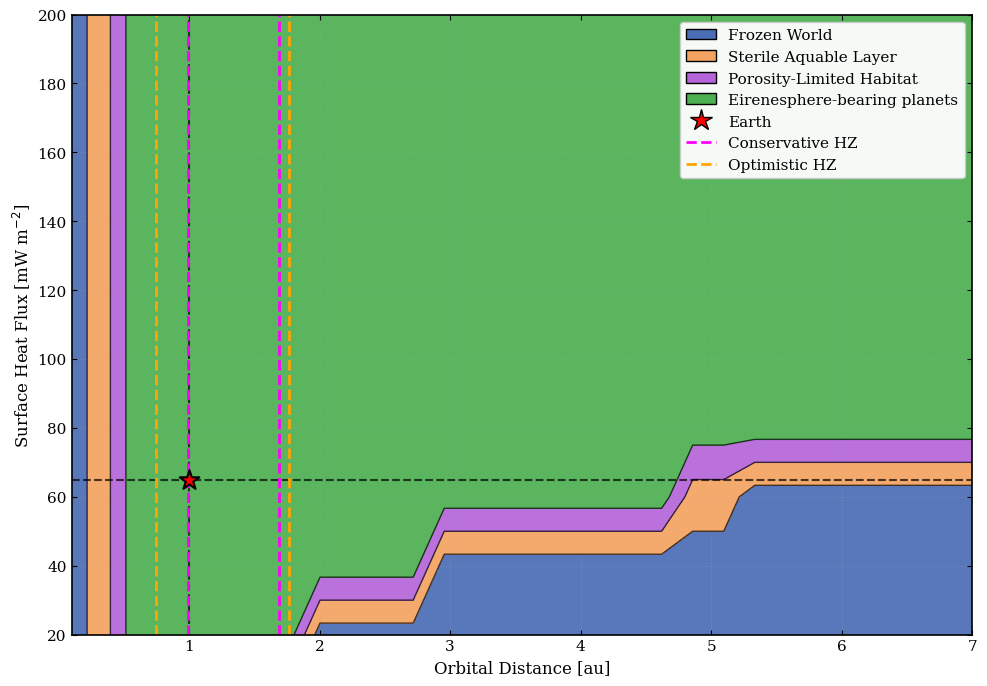


HABITABILITY REGIME STATISTICS

🧊 Frozen worlds: 58/300 (19.3%)

🌊 Liquid water but sterile: 12/300 (4.0%)

🪨 Porosity-limited habitats: 0/300 (0.0%)

🦠 Eirenesphere-bearing planets: 230/300 (76.7%)


In [81]:
plot_habitability_regimes(regime_data, kopparapu_limits=distances_kopparapu)

### Water Phase Diagram

In [82]:
# 1) Sublimation Curve (Ice-Vapor)
Ts_subl = np.linspace(200, 273.16, 250)
Ps_subl = np.array([_Sublimation_Pressure(T) for T in Ts_subl])  # MPa

# 2) Vaporization Curve (LLiquid-Vapor) 
Ts_vap = np.linspace(273.16, 647.096, 400)
Ps_vap = np.array([IAPWS97(T=T, x=0).P for T in Ts_vap])  # MPa

# 3) Fusion Curve (Ice-Liquid) 
hielos = {
    "Ih":  (251.165, 273.16),
    "III": (251.166, 256.164),
    "V":   (256.165, 273.31),
    "VI":  (273.32, 355.0),
    "VII": (355.1, 647.096),
}

# 4) Aquable Zone (T_melt < T < T_boil)
P_zone = np.logspace(-4, 3, 500)  # MPa
T_melt = np.array([hc.T_melting_IAPWS(P * 1e6, salinity=0.0) for P in P_zone])   # K
T_boil = np.array([hc.T_boiling_IAPWS(P * 1e6, salinity=0.0) for P in P_zone])    # K

mask_liquid = (~np.isnan(T_melt)) & (~np.isnan(T_boil)) & (T_boil > T_melt)
P_liquid = P_zone[mask_liquid]
T_melt_liquid = T_melt[mask_liquid]
T_boil_liquid = T_boil[mask_liquid]

# 5) Reference Pressure Lines
P_triple = 611.657e-6   # MPa
P_1atm = 0.101325       # MPa
P_high = 100.0          # MPa 



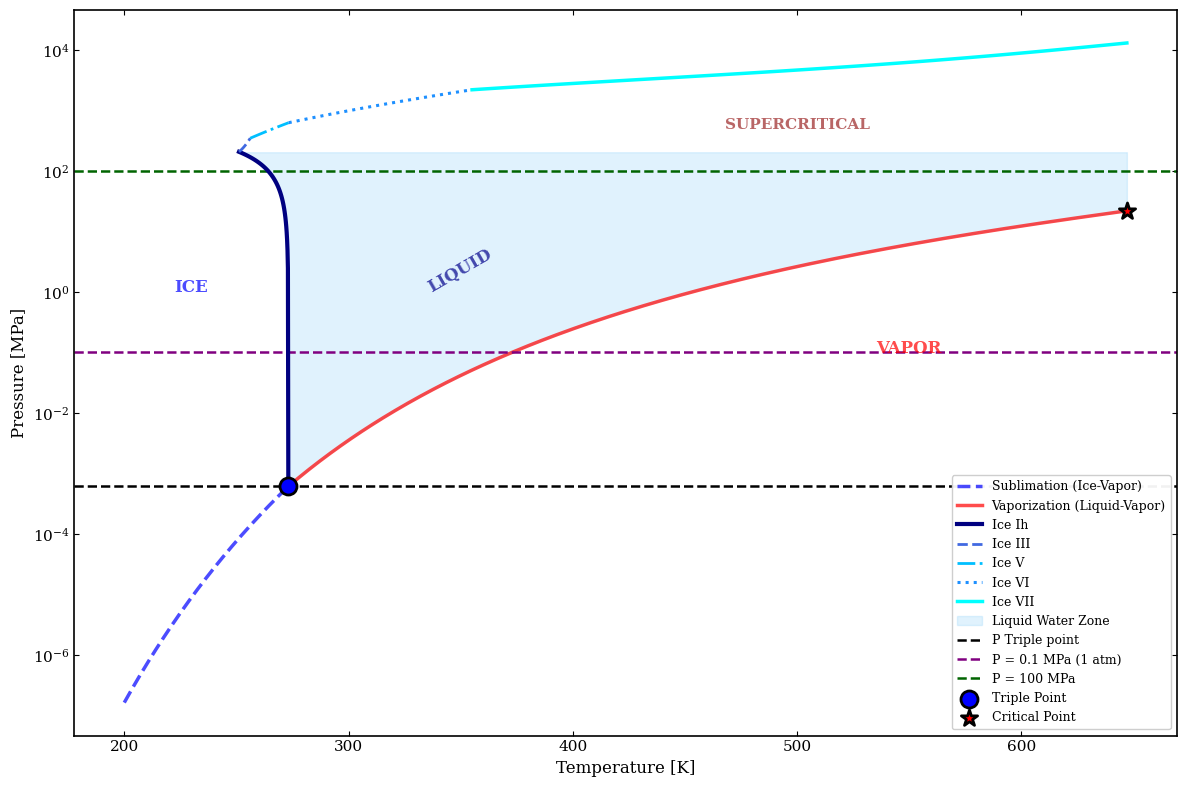

In [83]:

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(Ts_subl, Ps_subl, 'b--', linewidth=2.5, label='Sublimation (Ice-Vapor)', alpha=0.7)
ax.plot(Ts_vap, Ps_vap, 'r-', linewidth=2.5, label='Vaporization (Liquid-Vapor)', alpha=0.7)

ice_styles = {
    "Ih":  {"color": "navy",       "lw": 3.0, "ls": "-"},
    "III": {"color": "royalblue",  "lw": 2.0, "ls": "--"},
    "V":   {"color": "deepskyblue","lw": 2.0, "ls": "-."},
    "VI":  {"color": "dodgerblue", "lw": 2.2, "ls": ":"},
    "VII": {"color": "cyan",       "lw": 2.5, "ls": "-"},
}

for ice, (T0, T1) in hielos.items():
    Ts_freeze = np.linspace(T0, T1, 120)
    Ps_freeze = np.array([_Melting_Pressure(T, ice=ice) for T in Ts_freeze])

    style = ice_styles[ice]

    ax.plot(
        Ts_freeze, Ps_freeze,
        color=style["color"],
        linewidth=style["lw"],
        linestyle=style["ls"],
        label=f'Ice {ice}',
        zorder=3
    )


if P_liquid.size > 0:
    ax.fill_betweenx(
        P_liquid,
        T_melt_liquid,
        T_boil_liquid,
        color='lightskyblue',
        alpha=0.25,
        label='Liquid Water Zone',
        zorder=1
    )

ax.axhline(P_triple, color='black', ls='--', lw=1.8, label='P Triple point')
ax.axhline(P_1atm, color='purple', ls='--', lw=1.8, label='P = 0.1 MPa (1 atm)')
ax.axhline(P_high, color='darkgreen', ls='--', lw=1.8, label='P = 100 MPa')

# 
ax.set_xlabel('Temperature [K]', fontsize=12)
ax.set_ylabel('Pressure [MPa]', fontsize=12)
ax.set_yscale('log')

ax.grid(True, which='both', ls=':', alpha=0.35)

ax.text(230, 1, 'ICE', fontsize=12, fontweight='bold', 
       color='blue', ha='center', alpha=0.7)
ax.text(350, 1, 'LIQUID', fontsize=12, fontweight='bold', 
       color='darkblue', ha='center', alpha=0.7,rotation=30)
ax.text(550, 1e-1, 'VAPOR', fontsize=12, fontweight='bold', 
       color='red', ha='center', alpha=0.7)
ax.text(500, 5e2, 'SUPERCRITICAL', fontsize=11, fontweight='bold', 
       color='darkred', ha='center', alpha=0.6)

ax.scatter(273.16, 611.657e-6, color='blue', s=150, marker='o', 
          edgecolors='black', linewidths=2, label='Triple Point', zorder=10)
ax.scatter(647.096, 22.064, color='red', s=150, marker='*', 
          edgecolors='black', linewidths=2, label='Critical Point', zorder=10)

ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.grid()
plt.show()